In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from statsmodels.regression.linear_model import OLS
from sklearn.preprocessing import PolynomialFeatures
#import linear_regression
from matplotlib.patches import Rectangle
from functions import *
from matplotlib.patches import Rectangle

## Load in Data

In [ ]:
#Read in data file (see data_processing.ipynb for how this file is generated)
#Keep only Lec, CG, WG, and SQ codes (see paper for discussion of feature selection)
codes_and_CIs = pd.read_csv('Published Data/combined_COPUS_CI_data.csv')

#these will be input features for the model
data = codes_and_CIs[['Lec', 'CG', 'WG', 'SQ',]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

#The target variable is the effect size
target = codes_and_CIs['Effect Size'].to_numpy()



57

## Feature Selection

We use the Aiken .... 

We need to pick which of the cross terms are relvant to the model

In [ ]:
#Establish baseline AIC with all features
n = 1

AIC = 0
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=1,)

    regr = OLS(y_train, X_train).fit()
    AIC += aic_correction(regr.aic, X_train)
true_base_AIC = AIC / 10

In [ ]:
#its sets the number of different orders of variables to try
its =100000

#empty arrays to store which features are retained and associated AICS
AICs = np.zeros(its)
keepers = np.zeros((its, data.shape[1]), dtype=bool)
for j in range(its):
    base_AIC = true_base_AIC * 1

    #randomly shuffle order of variables
    shuffle = np.random.permutation(data.shape[1])
    pruned_data = data[:, shuffle]
    i = 0
    keeping = []
    while i < pruned_data.shape[1]:
        #initialize AIC
        AIC = 0
        #run regression n times with n different subsets of the training data
        for k in range(n):
            
            cut_data = np.delete(pruned_data, i, axis=1)

            delete_set = np.random.randint(0, cut_data.shape[0], 1)
            cut_data = np.delete(cut_data, delete_set, axis=0)
            cut_truth = np.delete(target, delete_set, axis=0)
            
            regr = OLS(cut_truth, cut_data).fit()
            #regr = OLS(truth, cut_data).fit()
            AIC += aic_correction(regr.aic, cut_data)
        #take average AIC over n runs
        av_AIC = AIC / n
        #if AIC improves by removing variable, permanently remove it
        if av_AIC - 1 < base_AIC  :

            pruned_data = np.delete(pruned_data, i, axis=1)
            base_AIC = av_AIC
        #otherwise keep the variable and move to the next one
        else:
            keepers[j, shuffle[i + (data.shape[1] - pruned_data.shape[1])]] = 1

            keeping.append(i + (data.shape[1] - pruned_data.shape[1]))
            i += 1
    AICs[j] = base_AIC
    if not j % 1000:
        print(f'Iteration {j + 1} finished with AIC {base_AIC.round(2)}')

np.save('weights/keepers.npy', keepers)
np.save('weights/AICs.npy', AICs)

Iteration 1 finished with AIC 44.73
Iteration 1001 finished with AIC 49.64
Iteration 2001 finished with AIC 54.31
Iteration 3001 finished with AIC 48.31
Iteration 4001 finished with AIC 48.8
Iteration 5001 finished with AIC 106.8
Iteration 6001 finished with AIC 59.83
Iteration 7001 finished with AIC 44.51
Iteration 8001 finished with AIC 38.37
Iteration 9001 finished with AIC 132.76
Iteration 10001 finished with AIC 43.7
Iteration 11001 finished with AIC 47.29
Iteration 12001 finished with AIC 71.81
Iteration 13001 finished with AIC 83.14
Iteration 14001 finished with AIC 37.04
Iteration 15001 finished with AIC 62.07
Iteration 16001 finished with AIC 41.7
Iteration 17001 finished with AIC 81.11
Iteration 18001 finished with AIC 42.57
Iteration 19001 finished with AIC 74.38
Iteration 20001 finished with AIC 126.51
Iteration 21001 finished with AIC 44.3
Iteration 22001 finished with AIC 45.78
Iteration 23001 finished with AIC 118.86
Iteration 24001 finished with AIC 61.03
Iteration 2500

## Leave-One-Out Testing



In [37]:
keepers = np.load('weights/keepers.npy')
AICs = np.load('weights/AICs.npy')
#pick the number of best fits to consider
num_choose = int(10)
good_fits = np.argsort(AICs - np.min(AICs))[:num_choose] 
bootstrap_n = 500
LOO_predictions = np.zeros((len(good_fits), bootstrap_n, data.shape[0]))

# Store LOO weights for each fit and each data point
LOO_weights = np.zeros((len(good_fits), bootstrap_n, data.shape[0], data.shape[1]))
#perform leave-one-out cross-validation for each of the best fits
for k in range(len(good_fits)):
    for l in range(bootstrap_n):
        for i in range(data.shape[0]):
            cut_data = np.delete(data[:, keepers[good_fits][k]], i, axis=0)
            cut_truth = np.delete(target, i, axis=0)
            #select .85 of the remaining data for training
            cut_data, _, cut_truth, _ = train_test_split(cut_data, cut_truth, test_size=.1)
            regr = OLS(cut_truth, cut_data).fit()
            params = regr.params
            LOO_predictions[k, l, i] = data[i, keepers[good_fits][k]] @ params
            # Store weights for this LOO fit
            LOO_weights[k, l, i, keepers[good_fits][k]] = params

#average over feature sets
LOO_predictions = np.mean(LOO_predictions, axis=0)

#find mean and standard deviation of predictions for each data point across all LOO fits
LOO_predictions_mean = np.mean(LOO_predictions, axis=0)
LOO_predictions_std = np.std(LOO_predictions, axis=0)


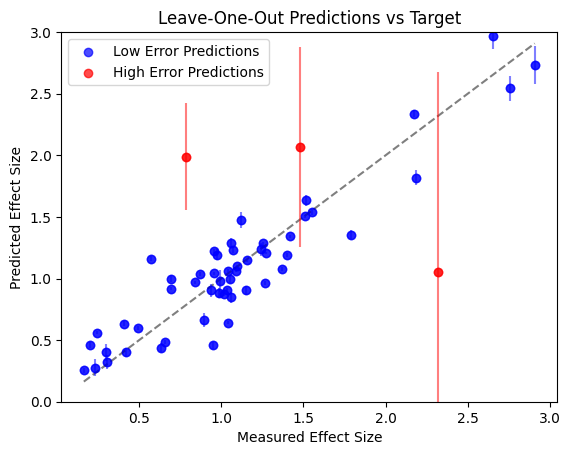

Correlation: 0.553
R^2: 0.306
Mean absolute error: 0.3476
Correlation removing high error: 0.931
R^2 removing high error: 0.867
MAE removing high error: 0.1735


In [97]:
x, y = target, LOO_predictions_mean
plt.plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)

where_low_error = np.where(LOO_predictions_std < .3)
where_high_error = np.where(LOO_predictions_std >= .3)
low_x, low_y = x[where_low_error], y[where_low_error]
high_x, high_y = x[where_high_error], y[where_high_error]

m, b = np.polyfit(x, y, 1)
xi = np.linspace(np.min(x), np.max(x), 100)


plt.scatter(low_x, low_y, label='Low Error Predictions', color='blue', alpha=0.7)
plt.errorbar(low_x, low_y, yerr=LOO_predictions_std[where_low_error], fmt='o', color='blue', alpha=0.5)

plt.scatter(high_x, high_y, label='High Error Predictions', color='red', alpha=0.7)
plt.errorbar(high_x, high_y, yerr=LOO_predictions_std[where_high_error], fmt='o', color='red', alpha=0.5)

plt.xlabel(f'Measured Effect Size')
plt.ylabel(f'Predicted Effect Size')
plt.ylim(0, 3)
plt.title(f'Leave-One-Out Predictions vs Target')
plt.legend()
plt.show()

print(f'Correlation: {np.corrcoef(x, y)[0, 1]:.3f}')
print(f'R^2: {np.corrcoef(x, y)[0, 1]**2:.3f}')
print(f'Mean absolute error: {np.mean(np.abs(y-x)):.4f}')

print(f'Correlation removing high error: {np.corrcoef(low_x, low_y)[0, 1]:.3f}')
print(f'R^2 removing high error: {np.corrcoef(low_x, low_y)[0, 1]**2:.3f}')
print(f'MAE removing high error: {np.mean(np.abs(low_y-low_x)):.4f}')

## Leave One Out Tests by Field and Class Size

Physics MAE: 0.1531
Biology MAE: 0.1896
Astronomy MAE: 0.1290


(0.0, 3.0)

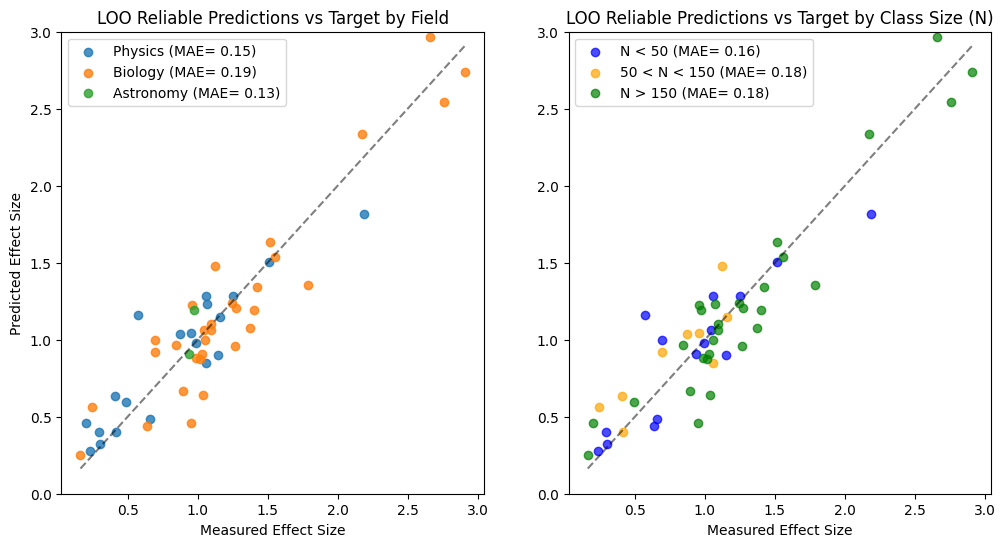

In [104]:
x, y = target, LOO_predictions_mean
#cut unreliable predictions
x, y = x[LOO_predictions_std < .3], y[LOO_predictions_std < .3]
fields = codes_and_CIs['Field'].values
Ns = codes_and_CIs['N'].values
fields, Ns = fields[LOO_predictions_std < .3], Ns[LOO_predictions_std < .3]


fig, ax = plt.subplots(1, 2, figsize=(12, 6))



#show points colored by field
for field in np.unique(fields)[::-1]:
    field_x = x[fields == field]
    field_y = y[fields == field]
    ax[0].scatter(field_x, field_y, label=field + f' (MAE= {np.mean(np.abs(field_y-field_x)):.2f})', alpha=0.8)
    print(f'{field} MAE: {np.mean(np.abs(field_y-field_x)):.4f}')

ax[0].plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)
ax[0].set_xlabel(f'Measured Effect Size')
ax[0].set_ylabel(f'Predicted Effect Size')
ax[0].legend()
ax[0].set_title(f'LOO Reliable Predictions vs Target by Field')
ax[0].set_ylim(0, 3)

#separately plot N < 50  50 < N < 100, and N > 100
N_labels = ['N < 50', '50 < N < 150', 'N > 150']
for N_range, color, label in zip([(0, 50), (50, 150),  (150, np.inf)], ['blue', 'orange', 'green'], N_labels):
    range_x = x[(Ns > N_range[0]) & (Ns <= N_range[1])]
    range_y = y[(Ns > N_range[0]) & (Ns <= N_range[1])]
    ax[1].scatter(range_x, range_y, label=label + f' (MAE= {np.mean(np.abs(range_y-range_x)):.2f})', alpha=0.7, color=color)
ax[1].legend()
ax[1].set_title(f'LOO Reliable Predictions vs Target by Class Size (N)')
ax[1].plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)
ax[1].set_xlabel(f'Measured Effect Size')
ax[1].set_ylim(0, 3)


In [46]:
data[np.where(LOO_predictions_std > .5), :4]

array([[[0.48944444, 0.61722222, 0.02777778, 0.        ],
        [0.02683843, 0.        , 1.        , 0.        ],
        [0.        , 0.        , 0.90990991, 0.04504504]]])

## Model Weight Training and Bootstrap Error on Model Weights

In [52]:

#set number of iterations
n = 1000
# Empty array to store bootstrap weights for each fit and each data point
bootstrap_weights = np.zeros((len(good_fits), n, data.shape[1]))
for i in range(n):
    #randomly cut 15% of training data
    sample_indices = np.random.permutation(data.shape[0])[:int(.85*data.shape[0])]
    #for each of the selected feature sets, train on remaining 85% and save weights
    for k in range(len(good_fits)):

        boot_data = data[sample_indices][:, keepers[good_fits][k]]
        boot_truth = target[sample_indices]
        regr = OLS(boot_truth, boot_data).fit()
        params = regr.params
        # Store weights for this bootstrap fit
        bootstrap_weights[k, i, keepers[good_fits][k]] = params

#average bootstrap weights across all feature selections        
mean_bootstrap_weights = np.mean(bootstrap_weights, axis=0)


## Testing on New Data

Mean Absolute Error: 0.271
Mean Absolute Error (removing high error): 0.1732
R^2: 0.127
R^2 (removing high error): 0.48


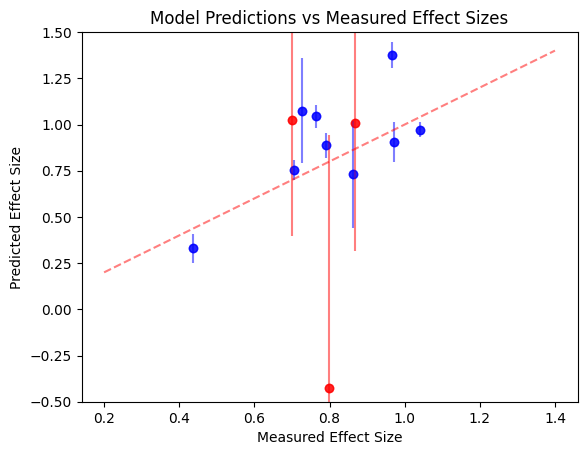

In [72]:
measured_data = pd.read_csv('Measured Data/measured_data.csv')
#Remove classes with pretest means > .6
measured_data = measured_data[measured_data['PreMean'] < .6]


measured_COPUS_data = measured_data[['Lec', 'CG', 'WG', 'SQ']].values
measured_effect_sizes = measured_data['Effect Size'].values

measurement_predictions = add_cross_terms(measured_COPUS_data) @ mean_bootstrap_weights.T
mean_measurement_predictions = np.mean(measurement_predictions, axis=1)
measurement_bootstrap_errors = np.std(measurement_predictions, axis=1)

where_low_error = np.where(measurement_bootstrap_errors < .3)
where_high_error = np.where(measurement_bootstrap_errors >= .3)
low_x, low_y = measured_effect_sizes[where_low_error], mean_measurement_predictions[where_low_error]
high_x, high_y = measured_effect_sizes[where_high_error], mean_measurement_predictions[where_high_error]

plt.scatter(low_x, low_y, label='Low Error Predictions', color='blue', alpha=0.7)
plt.errorbar(low_x, low_y, yerr=measurement_bootstrap_errors[where_low_error], fmt='o', color='blue', alpha=0.5)

plt.scatter(high_x, high_y, label='High Error Predictions', color='red', alpha=0.7)
plt.errorbar(high_x, high_y, yerr=measurement_bootstrap_errors[where_high_error], fmt='o', color='red', alpha=0.5)

plt.plot([.2, 1.4], [.2, 1.4], 'r--', alpha=0.5)
plt.ylim(-.5, 1.5)
plt.xlabel('Measured Effect Size')
plt.ylabel('Predicted Effect Size')
plt.title('Model Predictions vs Measured Effect Sizes')

print('Mean Absolute Error:', np.round(np.mean(np.abs(mean_measurement_predictions - measured_effect_sizes)), 3))
print('Mean Absolute Error (removing high error):', np.round(np.mean(np.abs(low_y - low_x)), 4))
print('R^2:', np.round(np.corrcoef(measured_effect_sizes, mean_measurement_predictions)[0, 1]**2, 3))
print('R^2 (removing high error):', np.round(np.corrcoef(low_x, low_y)[0, 1]**2, 3))

In [ ]:
measured_COPUS_data[np.where(measurement_bootstrap_errors > .4)]

array([[0.365, 0.5  , 0.   , 0.135],
       [0.377, 0.506, 0.   , 0.143],
       [0.551, 0.551, 0.   , 0.051]])

## Retrain Model Weights with new data

In [ ]:
all_data = np.vstack((data, add_cross_terms(measured_COPUS_data)))
all_target = np.hstack((target, measured_effect_sizes))

print(all_data.shape, all_target.shape)


for i in range(n):
    #randomly cut 15% of training data
    sample_indices = np.random.permutation(all_data.shape[0])[:int(.85*all_data.shape[0])]
    #for each of the selected feature sets, train on remaining 85% and save weights
    for k in range(len(good_fits)):

        boot_data = all_data[sample_indices][:, keepers[good_fits][k]]
        boot_truth = all_target[sample_indices]
        regr = OLS(boot_truth, boot_data).fit()
        params = regr.params
        # Store weights for this bootstrap fit
        bootstrap_weights[k, i, keepers[good_fits][k]] = params

#average bootstrap weights across all feature selections        
mean_bootstrap_weights = np.mean(bootstrap_weights.reshape(-1, data.shape[1]), axis=0)
#np.save('weights/bootstrap_weights.npy', bootstrap_weights)
#np.save('weights/mean_bootstrap_weights.npy', mean_bootstrap_weights)

(69, 39) (69,)


## Heatmap of Predicted Effect Sizes
For each simulated class profile, we assume that the instructor is spending all time outside of clickers and worksheets on lecture.
Numerically, this is defined as Lec = 1 - WG -  CG

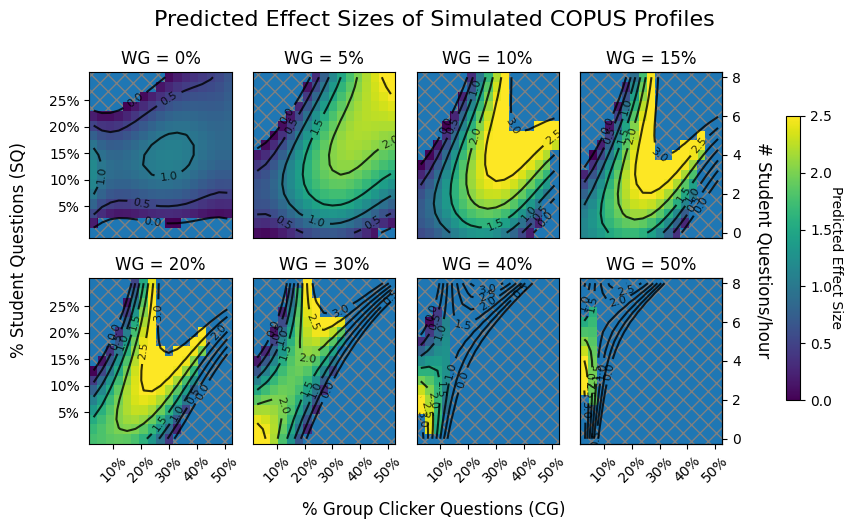

In [ ]:

# define paramater arrays for plotting
CG_interval = 1.8 / 30 / 2 #the average clicker question lasts 1.8 intervals
SQ_interval = 1.1 / 30 / 2 #the average student question lasts 1.1 intervals
CGs = np.arange(0, .5, CG_interval) #############################3 make smaller again
SQs = np.arange(0, .3 , SQ_interval)
CG_len, SQ_len = len(CGs), len(SQs)
CG_gap, SQ_gap = (CGs[1] - CGs[0])/2, (SQs[1] - SQs[0])/2
WGs = np.round(np.linspace(0, .4, 9), 2)
WGs = [0, .05, .1, .15, .2,  .3, .4, .5 ]

num_cols = 4
fig, ax = plt.subplots( int(len(WGs)/num_cols), num_cols,  figsize=( 8, int(2.5/num_cols*len(WGs)),))

for i in range(len(WGs)):
    ax_y, ax_x = i%num_cols, i//num_cols
    image = np.zeros((CG_len, SQ_len ))
    stds = np.zeros((CG_len, SQ_len ))

    for l in range(CG_len):
        lec =  np.maximum((1  -  WGs[i] -  CGs[l] ), 0)
        for m in range(SQ_len):
            test_point = np.array([lec, CGs[l], WGs[i], SQs[m]])
            test_point = add_cross_terms(test_point.reshape(1, -1))

            test_grid_predictions = np.mean(bootstrap_weights, axis = 0) @ test_point.T
            image[l, m] = np.mean(test_grid_predictions)
            stds[l, m] = np.std(test_grid_predictions)
                
    CG_max = np.minimum(np.max(CGs), np.maximum(0, (1 - WGs[i]) ))
    SQ_max = np.minimum(np.max(SQs), np.maximum(0, (1 - WGs[i]) ))
    image = image.T
    stds = stds.T

    
    c = ax[ax_x, ax_y].imshow(image, origin='lower', aspect='auto', 
                        extent=( 0 , CG_max + CG_interval   , 0 ,  SQ_max + SQ_interval  ,), cmap='viridis', vmin = 0, vmax=2.5)


    ac = ax[ax_x, ax_y].contour( CGs + CG_gap, SQs + SQ_gap,  image, levels=np.array([ 0, .5, 1, 1.5, 2, 2.5, 3]), colors='k', alpha=0.8,)
            #labels = [f'{level:.1f}' for level in [.2,  .4, .6, .8, .9]])
    ax[ax_x, ax_y].clabel(ac, inline=True, fontsize=8, fmt='%.1f', colors='k')


    #shade regions where model error is high or predicted values are outside the range of the training data
    err_threshhold = .3
    rows, cols = np.where((stds.T > err_threshhold) + (image.T < 0 ) + (
        image.T > 3))
    for row, col in zip(rows, cols):
        y = SQs[col]
        x = CGs[row]
        dy = SQ_interval 
        dx = CG_interval 
        rect = Rectangle((x, y), dx, dy, fill=True, hatch='xx', edgecolor='gray', linewidth=0, )#alpha = np.minimum(3, 3*stds[col, row])/3)
        ax[ax_x, ax_y].add_patch(rect)

    ax[ax_x, ax_y].set_title(f'WG = {int(100*WGs[i])}%')
    
    if i > 3:
        ax[ax_x, ax_y].set_xticks([.1, .2, .3, .4, .5] - CG_gap, np.array(['10%', '20%', '30%', '40%', '50%'] ), rotation=45)
    else: #remove ticks
        ax[ax_x, ax_y].set_xticks([])
    #create a second y-axis on the right to show number of student questions
    if i in [3, 7]: #only add y-axis labels to the middle two plots to avoid clutter
        ax2 = ax[ax_x, ax_y].twinx()
        ax2.set_ylim(ax[ax_x, ax_y].get_ylim())
        ax2.set_yticks(.11/3 *np.array([0, 2, 4, 6, 8])  +SQ_gap, np.array(['0', '2', '4', '6', '8' ]))
    if i in [0, 4]:
        ax[ax_x, ax_y].set_yticks(np.array([.05, .1, .15, .2, .25]) +SQ_gap, np.array(['5%', '10%', '15%', '20%', '25%']))
    else: # no y ticks
        ax[ax_x, ax_y].set_yticks([])


fig.text(.9, .5, '# Student Questions/hour', rotation=-90, va='center', ha='left', fontsize=12)    
fig.text(0.5, -0.03, '% Group Clicker Questions (CG)', ha='center', fontsize=12)
fig.text(-0.03, 0.5, '% Student Questions (SQ)', va='center', rotation='vertical', fontsize=12)
fig.suptitle(f'Predicted Effect Sizes of Simulated COPUS Profiles', fontsize=16)

plt.tight_layout()
#colorbar
cbar = fig.colorbar(c, ax=ax.ravel().tolist(), orientation='vertical', fraction=0.02, pad= .09)
cbar.set_label(f'Predicted Effect Size',  rotation=270, labelpad=8,)
cbar.ax.xaxis.set_label_position('top')
    


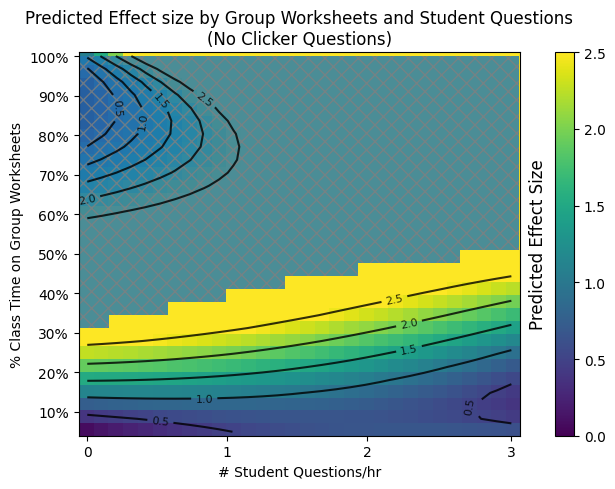

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

WGs = np.linspace(.05, 1, 30)
SQs = np.linspace(0, .1, 30)
image = np.zeros((len(WGs), len(SQs)))
stds = np.zeros((len(WGs), len(SQs)))
for i in range(len(WGs)):
    for j in range(len(SQs)):
        test_point = np.array([1 - WGs[i], 0, WGs[i], SQs[j]])
        test_point = add_cross_terms(test_point.reshape(1, -1))
        test_grid_predictions = np.mean(bootstrap_weights, axis = 0) @ test_point.T
        image[i, j] = np.mean(test_grid_predictions)
        stds[i, j] = np.std(test_grid_predictions)

#shade regions where model error is high or predicted values are outside the range of the training data
rows, cols = np.where((stds > err_threshhold) + (image < np.min(target) - err_threshhold) + (image > np.max(target) + err_threshhold))


for row, col in zip(rows, cols):
    x = SQs[col]
    y = WGs[row]
    dx = SQs[1] - SQs[0]  # width of one cell
    dy = WGs[1] - WGs[0]  # height of one cell
    rect = Rectangle((x - dx/2, y - dy), dx, dy, fill=True, alpha = .8, hatch='xx', edgecolor='gray', linewidth=0)
    ax.add_patch(rect)




c = ax.imshow(image, origin='lower', aspect='auto', 
                        extent=(-.002, np.max(SQs) + .002, np.min(WGs)- .01, 1.01), cmap='viridis', vmin = 0, vmax=2.5)
ac = ax.contour(SQs, WGs, image, levels=np.array([ .5, 1, 1.5, 2, 2.5]), colors='k', alpha=0.8,)

ax.clabel(ac, inline=True, fontsize=8, fmt='%.1f', colors='k')

#d= ax.contour(SQs, WGs, stds, levels=np.array([   .4, .5, .8 ]), colors='white', alpha=1, )
#ax.clabel(d, inline=True, fontsize=8, fmt='%.2f', colors='gray',)
ax.set_xticks(np.array([0, .033, .066, .1]), labels=np.array(['0', '1', '2', '3']))
ax.set_yticks(np.array([.1, .2, .3, .4, .5, .6, .7, .8, .9, 1]), labels=np.array(['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']))
plt.xlim(-.002, .102)
ax.set_xlabel('# Student Questions/hr')
ax.set_ylabel('% Class Time on Group Worksheets')
ax.set_title('Predicted Effect size by Group Worksheets and Student Questions\n(No Clicker Questions)')
plt.tight_layout()
#colorbar
cbar = fig.colorbar(c, ax=ax, orientation='vertical', fraction=0.05, pad= .07)
cbar.set_label(f'Predicted Effect Size',  rotation=90, labelpad=-55, fontsize = 12)